# Local Analogs selection

In [2]:
%matplotlib inline

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.io import fits
from astropy.table import Table
from astropy.coordinates import SkyCoord, FK5

In [8]:
# from google.colab import drive
drive.mount('/content/drive/')
ROOT='/content/drive/Shareddrives/TrainorFulbright/local-analogs-sample/BPT-analog-selection/'
# ROOT='/Users/javieratoro/Desktop/proyecto 2024-2/MPA-JHU/'

NameError: name 'drive' is not defined

## Merging SDSS catalogs

In [8]:
info = Table.read(ROOT+'galSpecInfo-dr8.fits', format='fits')
line = Table.read(ROOT+'galSpecLine-dr8.fits', format='fits').to_pandas()
extra = Table.read(ROOT+'galSpecExtra-dr8.fits', format='fits').to_pandas()

In [7]:
info

NameError: name 'info' is not defined

In [6]:
info = info[['SPECOBJID', 'RA', 'DEC', 'Z', 'Z_ERR', 'RELIABLE', 'PRIMTARGET', 'SECTARGET',
             'TARGETTYPE', 'SPECTROTYPE', 'SUBCLASS', 'Z_WARNING']].to_pandas()
usable = (info.RELIABLE == 1) & (info.RA>-99) & (info.DEC>-99)

info = info[usable]
line = line[usable]
extra = extra[usable]

NameError: name 'info' is not defined

In [10]:
full = pd.merge(info, line, on='SPECOBJID', how='inner')
full = pd.merge(full, extra, on='SPECOBJID', how='inner')

full['O32'] = full.OIII_5007_FLUX / (full.OII_3726_FLUX + full.OII_3729_FLUX)
full['R23'] = (full.OIII_5007_FLUX + full.OIII_4959_FLUX + full.OII_3726_FLUX + full.OII_3729_FLUX) / full.H_BETA_FLUX
full['SII_ratio'] = full.SII_6717_FLUX / full.SII_6731_FLUX
full['sSFR'] = full.SFR_TOT_P50 - full.LGM_TOT_P50
full['log_O3Hb'] = np.log10(full.OIII_5007_FLUX / full.H_BETA_FLUX)
full['log_N2Ha'] = np.log10(full.NII_6584_FLUX / full.H_ALPHA_FLUX)

# These will be useful to compare with previous catalogs
full_coords = SkyCoord(ra=full.RA, dec=full.DEC, unit='deg', frame=FK5, equinox='J2000.0')

/opt/anaconda3/envs/pypeit/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/pypeit/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/pypeit/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/pypeit/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


## Cut: Reliable

In [11]:
print("Catalog has : {} sources".format(len(full)))
selection = full.query('RELIABLE == 1')# and Z_WARNING == 0')
print("Catalog has : {} sources".format(len(selection)))

Catalog has : 926067 sources
Catalog has : 926067 sources


## Cut: S/N on important fluxes

In [12]:
selection = selection.query('OIII_5007_FLUX / OIII_5007_FLUX_ERR > 10. '
                            'and H_ALPHA_FLUX / H_ALPHA_FLUX_ERR > 10. '
                            'and H_BETA_FLUX / H_BETA_FLUX_ERR > 10. '
                            'and NII_6584_FLUX / NII_6584_FLUX_ERR > 3. '
                            'and SII_6717_FLUX / SII_6717_FLUX_ERR > 5. '
                            'and SII_6731_FLUX / SII_6731_FLUX_ERR > 5. '
                            'and OII_3729_FLUX / OII_3729_FLUX_ERR > 3.'
                           )
print("Catalog has : {} sources".format(len(selection)))

Catalog has : 127770 sources


## Cut: Redshift

In [13]:
selection = selection[selection.Z < 0.2]
# selection = selection[selection.Z < 0.08] # extending to get more targets
print("Catalog has : {} sources".format(len(selection)))

Catalog has : 122607 sources


## Cut: AGN

In [14]:
np.unique(selection.SUBCLASS)

array([b'                     ', b'AGN                  ',
       b'AGN BROADLINE        ', b'BROADLINE            ',
       b'STARBURST            ', b'STARBURST BROADLINE  ',
       b'STARFORMING          ', b'STARFORMING BROADLINE'], dtype=object)

In previous versions, I have selected only 'starburst' subclasses, I can't remember why. Now I will only remove obvious AGN.

In [15]:
# starbursts = [(b"STARBURST" in subclass) for subclass in selection.SUBCLASS]
# selection = selection[starbursts]
# print("Catalog has : {} sources".format(len(selection)))

In [16]:
# not_agn = [((b"AGN" not in subclass) and (b"BROADLINE" not in subclass)) for subclass in selection.SUBCLASS]
not_agn = [(b"AGN" not in subclass) for subclass in selection.SUBCLASS]
selection = selection[not_agn]
print("Catalog has : {} sources".format(len(selection)))

Catalog has : 114096 sources


In [17]:
print("The available subclasses are:")
print(np.unique(selection.SUBCLASS))

The available subclasses are:
[b'                     ' b'BROADLINE            '
 b'STARBURST            ' b'STARBURST BROADLINE  '
 b'STARFORMING          ' b'STARFORMING BROADLINE']


## BPT Selection

In [18]:
tolerance = 0.0  # We can play around with this number to increase the sample siz
# tolerance = 0.0

def min_O3Hb(x):
    return 1.14 + 0.66 / (x - 0.31) - tolerance

def max_O3Hb(x):
    return 1.19 + 0.61 / (x - 0.47)

bpt_selection = ((selection.log_O3Hb > min_O3Hb(selection.log_N2Ha)) &
                 (selection.log_O3Hb < max_O3Hb(selection.log_N2Ha)) &
                 (selection.log_N2Ha < -1))

print("There are {} sources selected".format(np.sum(bpt_selection)))

There are 100 sources selected


---

## BPT Figure

In [21]:
xedges = np.arange(-2, 0.6, 0.1)
yedges = np.arange(-1, 1.1, 0.1)
# H, xedges, yedges = np.histogram2d(np.log10(selection.NII_6584_FLUX / selection.H_ALPHA_FLUX).values,
#                                    np.log10(selection.OIII_5007_FLUX / selection.H_BETA_FLUX).values,
#                                    bins=(xedges, yedges))
# H = H.T
H = np.load(ROOT+'contours.npy')

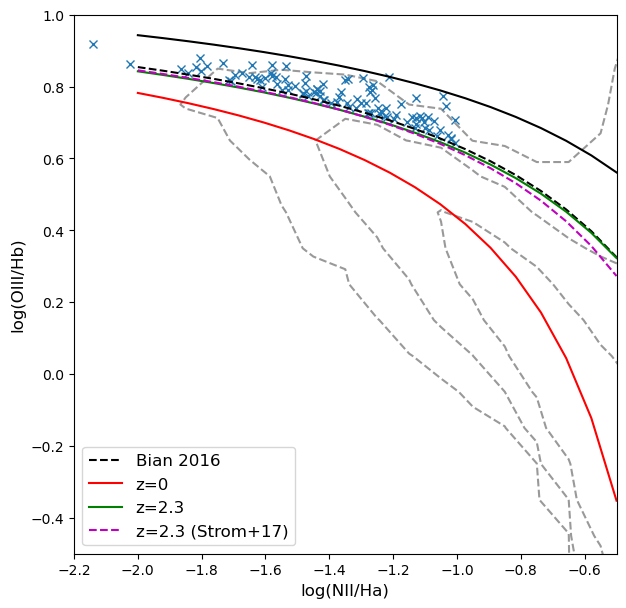

In [22]:
plt.figure(figsize=(7, 7))

x_centers = 0.5 * (xedges[1:] + xedges[:-1])
y_centers = 0.5 * (yedges[1:] + yedges[:-1])
plt.contour(x_centers, y_centers, H, [10, 100, 1000], origin='lower', linestyles='--', colors='0.6')

plt.plot(np.log10(selection[bpt_selection].NII_6584_FLUX /  selection[bpt_selection].H_ALPHA_FLUX),
         np.log10(selection[bpt_selection].OIII_5007_FLUX / selection[bpt_selection].H_BETA_FLUX), 'x')

x_boundaries = np.linspace(-2, -0.5, 20)

# y_boundaries_lo = min_O3Hb(x_boundaries)
y_boundaries_lo = 1.14 + 0.66 / (x_boundaries - 0.31)
y_boundaries_hi = max_O3Hb(x_boundaries)


z0 = 1.1 + 0.61 / (x_boundaries + 0.08)
z23 = 1.13 + 0.67 / (x_boundaries - 0.33)
z23_strom = 1.12 + 0.61 / (x_boundaries - 0.22) # Strom+ 2017

plt.plot(x_boundaries, y_boundaries_lo, 'k--', label='Bian 2016')
plt.plot(x_boundaries, y_boundaries_hi, 'k-')
plt.plot(x_boundaries, z0, 'r-', label='z=0')
plt.plot(x_boundaries, z23, 'g-', label='z=2.3')
plt.plot(x_boundaries, z23_strom, 'm--', label='z=2.3 (Strom+17)')


# plt.xlim(-2.2, .5)
# plt.ylim(-1, 1)

plt.xlim(-2.2, -.5)
plt.ylim(-0.5, 1)

plt.xlabel('log(NII/Ha)', fontsize=12)
plt.ylabel('log(OIII/Hb)', fontsize=12)

_ = plt.legend(loc='lower left', fontsize=12)

## Mass Distribution

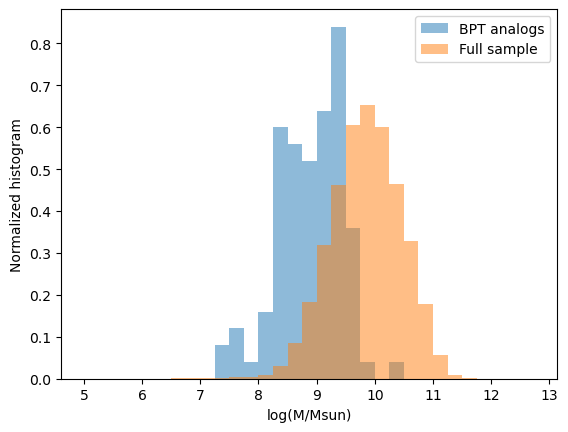

In [24]:
plt.hist(selection[bpt_selection].LGM_TOT_P50, bins=np.arange(5, 13, 0.25), density=True, alpha=0.5, label="BPT analogs")
plt.hist(selection.LGM_TOT_P50, bins=np.arange(5, 13, 0.25), density=True, alpha=0.5, label="Full sample")
plt.xlabel('log(M/Msun)')
plt.ylabel('Normalized histogram')
plt.legend()

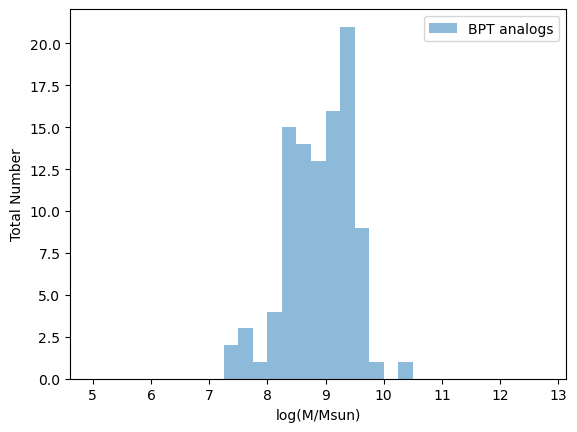

In [25]:
plt.hist(selection[bpt_selection].LGM_TOT_P50, bins=np.arange(5, 13, 0.25), density=False, alpha=0.5, label="BPT analogs")
plt.xlabel('log(M/Msun)')
plt.ylabel('Total Number')
plt.legend()

## BPT selection b/w SDSS and Strom+17 loci

In [1]:

tolerance = 0.0  # We can play around with this number to increase the sample siz
# tolerance = 0.0

def sdss_O3Hb(x):
    return 1.1 + 0.61 / (x + 0.08) - tolerance

def strom_O3Hb(x):
    return 1.12 + 0.61 / (x - 0.22)

def mid_O3Hb(x):
    return 0.5 * (sdss_O3Hb(x) + strom_O3Hb(x))

# bpt_selection_low = ((selection.log_O3Hb > mid_O3Hb(selection.log_N2Ha)) &
#                  (selection.log_O3Hb < max_O3Hb(selection.log_N2Ha)) &
#                  (selection.log_N2Ha < -0.7) & (selection.SFR_TOT_P50 > 0.75) &
#                  (selection.LGM_TOT_P50 > 9.5))

bpt_selection_low = ((selection.log_O3Hb > strom_O3Hb(selection.log_N2Ha)-0.05) &
                 (selection.log_O3Hb < max_O3Hb(selection.log_N2Ha)) &
                 (selection.log_N2Ha < -0.6) & (selection.SFR_TOT_P50 > 0.75) &
                 (selection.LGM_TOT_P50 > 9.5))

print("There are {} sources selected".format(np.sum(bpt_selection_low)))

NameError: name 'selection' is not defined

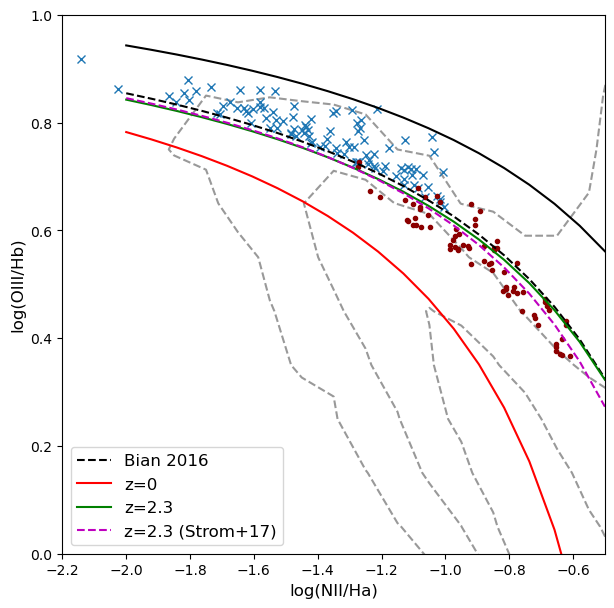

In [27]:
plt.figure(figsize=(7, 7))

x_centers = 0.5 * (xedges[1:] + xedges[:-1])
y_centers = 0.5 * (yedges[1:] + yedges[:-1])
plt.contour(x_centers, y_centers, H, [10, 100, 1000], origin='lower', linestyles='--', colors='0.6')

plt.plot(np.log10(selection[bpt_selection].NII_6584_FLUX /  selection[bpt_selection].H_ALPHA_FLUX),
         np.log10(selection[bpt_selection].OIII_5007_FLUX / selection[bpt_selection].H_BETA_FLUX), 'x')
plt.plot(np.log10(selection[bpt_selection_low].NII_6584_FLUX /  selection[bpt_selection_low].H_ALPHA_FLUX),
         np.log10(selection[bpt_selection_low].OIII_5007_FLUX / selection[bpt_selection_low].H_BETA_FLUX), '.',color='darkred')

x_boundaries = np.linspace(-2, -0.5, 20)

# y_boundaries_lo = min_O3Hb(x_boundaries)
y_boundaries_lo = 1.14 + 0.66 / (x_boundaries - 0.31)
y_boundaries_hi = max_O3Hb(x_boundaries)


z0 = 1.1 + 0.61 / (x_boundaries + 0.08)
z23 = 1.13 + 0.67 / (x_boundaries - 0.33)
z23_strom = 1.12 + 0.61 / (x_boundaries - 0.22) # Strom+ 2017

plt.plot(x_boundaries, y_boundaries_lo, 'k--', label='Bian 2016')
plt.plot(x_boundaries, y_boundaries_hi, 'k-')
plt.plot(x_boundaries, z0, 'r-', label='z=0')
plt.plot(x_boundaries, z23, 'g-', label='z=2.3')
plt.plot(x_boundaries, z23_strom, 'm--', label='z=2.3 (Strom+17)')


# plt.xlim(-2.2, .5)
# plt.ylim(-1, 1)

plt.xlim(-2.2, -.5)
plt.ylim(-0, 1)

plt.xlabel('log(NII/Ha)', fontsize=12)
plt.ylabel('log(OIII/Hb)', fontsize=12)

_ = plt.legend(loc='lower left', fontsize=12)

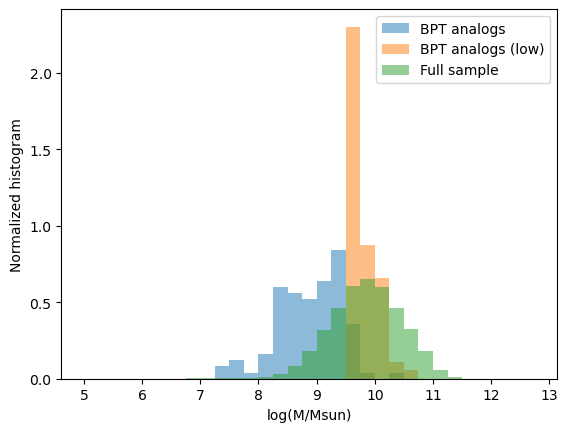

In [28]:
plt.hist(selection[bpt_selection].LGM_TOT_P50, bins=np.arange(5, 13, 0.25), density=True, alpha=0.5, label="BPT analogs")
plt.hist(selection[bpt_selection_low].LGM_TOT_P50, bins=np.arange(5, 13, 0.25), density=True, alpha=0.5, label="BPT analogs (low)")
plt.hist(selection.LGM_TOT_P50, bins=np.arange(5, 13, 0.25), density=True, alpha=0.5, label="Full sample")
plt.xlabel('log(M/Msun)')
plt.ylabel('Normalized histogram')
plt.legend()

In [29]:
# for col in selection[bpt_selection].columns:
#   print(col)

/var/folders/b3/z1vmt1t542ncmpppx7tfrqd80000gn/T/ipykernel_17658/1544163572.py:10: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


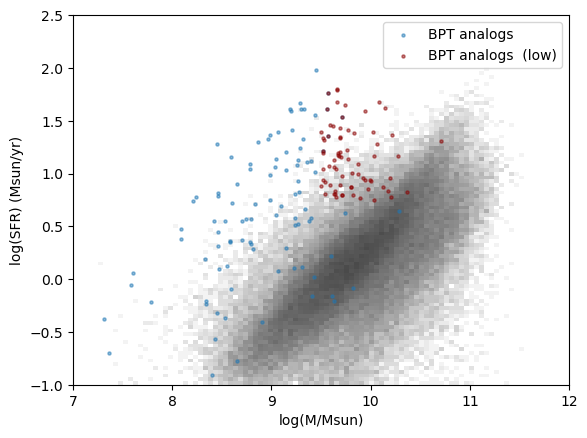

In [30]:
import matplotlib.colors as colors

# plt.scatter(selection.LGM_TOT_P50, selection.SFR_TOT_P50, alpha=0.01, label="Full sample", s=3,c='0.5')
out=plt.hist2d(selection.LGM_TOT_P50, selection.SFR_TOT_P50, bins=(np.linspace(7,12,100),np.linspace(-1,2.5,100)), label="Full sample",cmap='Greys',norm=colors.LogNorm(vmin=1, vmax=1000))
plt.scatter(selection[bpt_selection].LGM_TOT_P50, selection[bpt_selection].SFR_TOT_P50, alpha=0.5, s=5, label="BPT analogs")
plt.scatter(selection[bpt_selection_low].LGM_TOT_P50,selection[bpt_selection_low].SFR_TOT_P50, alpha=0.5, s=5,  label="BPT analogs  (low)",color='darkred')
plt.xlabel('log(M/Msun)')
plt.ylabel('log(SFR) (Msun/yr)')
plt.axis([7,12,-1,2.5])
plt.legend()

## Observability

In [31]:
candidates = selection[bpt_selection_low]

The semester runs from July 2024 to January 2025.

In [32]:
south = candidates.DEC < 16.5
print("Number of targets in the south: ", np.sum(south))

Number of targets in the south:  28


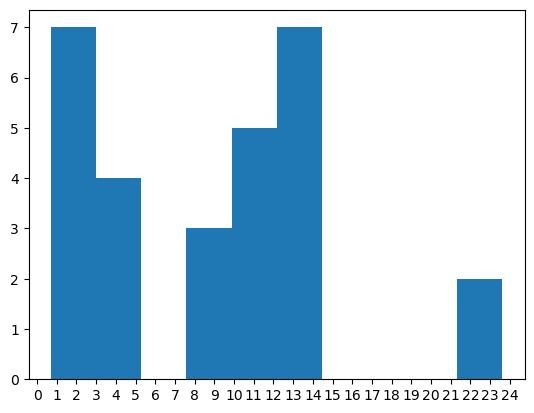

In [33]:
plt.hist(candidates[south].RA * 24 / 360)
plt.xticks(range(25));

Looks like from Oct 10 - Jan is the best time and we would have enought targets to fill up the night.

In [39]:
from astroplan import Observer, FixedTarget
# from astroplan.plots import plot_airmass
from astropy.time import Time
from datetime import datetime

In [40]:
LCO = Observer.at_site("Las Campanas Observatory")

In [41]:
times = ['2024-07-01 00:00:00.00',
         '2024-08-01 00:00:00.00',
         '2024-09-01 00:00:00.00',
         '2024-10-01 00:00:00.00',
         '2024-11-01 00:00:00.00',
         '2024-12-01 00:00:00.00',
         '2025-01-01 00:00:00.00',
        ]

In [42]:
LCO.local_sidereal_time(LCO.sun_set_time(Time(times), which='next'))

<Longitude [11.85494956, 14.15848134, 16.47453385, 18.70108681,
            21.06920927, 23.43880204,  1.75983903] hourangle>

In [43]:
np.sort(candidates[south].RA*24/360)

array([ 0.7145313,  0.8096233,  0.9242951,  0.9242951,  0.9242951,
        1.8475745,  1.8824278,  3.3873131,  3.481484 ,  3.481484 ,
        3.5553358,  9.299849 ,  9.822496 ,  9.8319025, 10.567826 ,
       11.568884 , 11.908865 , 11.912947 , 12.078738 , 12.626027 ,
       12.752515 , 12.9461775, 13.0220175, 13.460598 , 13.956508 ,
       14.291749 , 23.015116 , 23.60351  ], dtype=float32)

In [46]:
candidates[south][['RA', 'DEC']].sort_values('RA')

,RA,DEC
205003,10.717969,0.458358
80957,12.144349,15.384985
60323,13.864427,-0.363547
60839,13.864427,-0.363547
61358,13.864427,-0.363547
207699,27.713619,-0.962672
195082,28.236418,-8.317486
251751,50.809696,-0.740569
77084,52.222260,0.517834
77539,52.222260,0.517834
